Scikit-Learn `Pipeline` for Imputation, Scaling, and Encoding
This notebook explores the Scikit-Learn `Pipeline` object in depth, demonstrating how to chain preprocessing steps, inspect fitted internals, tune parameters, and persist the full workflow.

## 1. Why `Pipeline`?
- Encapsulates preprocessing and modeling in a single object.
- Prevents data leakage by applying transforms inside cross-validation.
- Makes workflows reproducible, readable, and easy to save/load.
- Ensures transforms are applied in the correct order.

In [1]:
# 2. Load libraries and the Titanic dataset
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import importlib.util
import joblib
import os

# Titanic dataset
print("\n[1/3] Titanic dataset...")
try:
    if not os.path.exists("data/titanic.csv"):
        df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
        df.to_csv('data/titanic.csv', index=False)
        print(f" Downloaded: {df.shape[0]} rows, {df.shape[1]} columns")
    else:
        print(" Already exists")
        df = pd.read_csv('data/titanic.csv')
except Exception as e:
    print(f"   Error: {e}")


[1/3] Titanic dataset...
   Error: Cannot save file into a non-existent directory: 'data'


## 3. Dataset preview and missing values
We use `titanic.csv` as a concrete example. The target is `survived`, and we will preprocess numerical and categorical features separately.

In [2]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Missing values:\n", df.isna().sum())

Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Missing values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## 4. Feature selection and column types
We split features into numerical and categorical groups and drop columns that are redundant or derived from the original data.

In [3]:
feature_columns = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]

target_column = "survived"

numeric_features = ["age", "sibsp", "parch", "fare"]
cat_features = ["pclass", "sex", "embarked"]

X = df[feature_columns]
y = df[target_column]

X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## 5. Pipeline anatomy and step semantics
A `Pipeline` is an ordered sequence of steps. Each step is a `(name, estimator)` pair.
- All steps except the final one must be transformers implementing `fit` and `transform`.
- The last step can be an estimator implementing `fit` and `predict`.

Common pipeline attributes:
- `steps`
- `named_steps`
- `fit`, `transform`, `fit_transform`
- `predict` (when final step is an estimator)

In [4]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
    ),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, cat_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000)),
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['pclass', 'sex',
                                                   'embarked'])])),
                ('clf', LogisticRegression(max_iter=1000))])

## 6. How pipeline execution works
- `fit(X, y)` calls `fit_transform` on each transformer step, then `fit` on the final estimator.
- `predict(X)` passes transformed features to the final estimator.
- The output of each step becomes the input to the next step.

This makes preprocessing automatic and ensures the same transformations are used at training and inference time.

In [5]:
# Train/test split and fit the pipeline
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print("Classification report:\n", classification_report(y_test, preds, digits=4))

Accuracy: 0.8044692737430168
Classification report:
               precision    recall  f1-score   support

           0     0.8099    0.8909    0.8485       110
           1     0.7931    0.6667    0.7244        69

    accuracy                         0.8045       179
   macro avg     0.8015    0.7788    0.7864       179
weighted avg     0.8034    0.8045    0.8007       179



## 7. Inspecting fitted pipeline internals
You can access intermediate transformers using `named_steps`, and inspect fitted attributes such as imputer statistics.

In [6]:
print("Pipeline steps:", pipeline.steps)
print("Named steps:", pipeline.named_steps.keys())

preprocessor_step = pipeline.named_steps["preprocessor"]
print(preprocessor_step)

numeric_step = preprocessor_step.named_transformers_["numeric"]
print("Numeric imputer strategy:", numeric_step.named_steps["imputer"].strategy)
print("Numeric imputer statistics:", numeric_step.named_steps["imputer"].statistics_)

cat_step = preprocessor_step.named_transformers_["categorical"]
print("Categorical categories:", cat_step.named_steps["onehot"].categories_)

Pipeline steps: [('preprocessor', ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'sibsp', 'parch', 'fare']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['pclass', 'sex', 'embarked'])])), ('clf', LogisticRegression(max_iter=1000))]
Named steps: dict_keys(['preprocessor', 'clf'])
ColumnTransformer(transform

## 8. Extracting transformed feature names
When using `OneHotEncoder` inside `ColumnTransformer`, we can inspect feature names after preprocessing.

In [7]:
output_feature_names = preprocessor_step.get_feature_names_out()
print("Transformed feature names:\n", output_feature_names)
print("Number of output features:", len(output_feature_names))

Transformed feature names:
 ['numeric__age' 'numeric__sibsp' 'numeric__parch' 'numeric__fare'
 'categorical__pclass_1' 'categorical__pclass_2' 'categorical__pclass_3'
 'categorical__sex_female' 'categorical__sex_male'
 'categorical__embarked_C' 'categorical__embarked_Q'
 'categorical__embarked_S']
Number of output features: 12


## 9. Adding PCA to the pipeline
PCA is a dimensionality reduction step that should come after scaling and encoding but before the final estimator.
This section shows how to insert `PCA` into the pipeline and inspect the explained variance.

In [8]:
# Build a pipeline that includes PCA after preprocessing
pipeline_with_pca = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=5)),
    ("clf", LogisticRegression(max_iter=1000)),
])

pipeline_with_pca.fit(X_train, y_train)

print("PCA components:", pipeline_with_pca.named_steps["pca"].n_components_)
print(
    "Explained variance ratio:",
    pipeline_with_pca.named_steps["pca"].explained_variance_ratio_
)
print(
    "Total explained variance (first 5 components):",
    pipeline_with_pca.named_steps["pca"].explained_variance_ratio_.sum(),
)

preds_pca = pipeline_with_pca.predict(X_test)
print("Accuracy with PCA:", accuracy_score(y_test, preds_pca))

PCA components: 5
Explained variance ratio: [0.29516691 0.23718227 0.13637875 0.11335427 0.07193317]
Total explained variance (first 5 components): 0.8540153695402098
Accuracy with PCA: 0.8044692737430168


## 10. Parameter access and tuning
Use `get_params()` and `set_params()` to inspect or change pipeline settings.
Parameter names follow the convention `step__parameter`.

In [9]:
params = pipeline.get_params()
print("Example parameter keys:")
for key in sorted(params)[:20]:
    print(key)

# Change a parameter in a nested step
pipeline.set_params(preprocessor__numeric__imputer__strategy="mean")
print("Updated imputer strategy:", pipeline.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["imputer"].strategy)

Example parameter keys:
clf
clf__C
clf__class_weight
clf__dual
clf__fit_intercept
clf__intercept_scaling
clf__l1_ratio
clf__max_iter
clf__multi_class
clf__n_jobs
clf__penalty
clf__random_state
clf__solver
clf__tol
clf__verbose
clf__warm_start
memory
preprocessor
preprocessor__categorical
preprocessor__categorical__imputer
Updated imputer strategy: median


## 10. `Pipeline` debugging notes
- The final step must support `predict` or `transform` depending on usage.
- Avoid placing an estimator before the last step.
- Use `verbose=2` to see the order of transforms during `fit`.
- Use `memory` when transforms are expensive and repeated across runs.

In [10]:
# Rebuild with verbose output to illustrate execution order
pipeline_verbose = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(max_iter=1000)),
    ],
    verbose=True,
)

pipeline_verbose.fit(X_train, y_train)

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing clf, total=   0.0s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['pclass', 'sex',
                                                   'embarked'])])),
                ('clf', LogisticRegression(max_iter=1000))],
         verbose=True)

## 11. Save and reload the pipeline
Saving the pipeline preserves preprocessing and the trained model together. This is ideal for deployment and future inference.

In [11]:
filename = "titanic_pipeline.joblib"
joblib.dump(pipeline, filename)
loaded_pipeline = joblib.load(filename)

print("Loaded pipeline score:", loaded_pipeline.score(X_test, y_test))

new_example = X_test.iloc[[0]]
print("Predicted class:", loaded_pipeline.predict(new_example))
print("Input row:\n", new_example)

Loaded pipeline score: 0.8044692737430168
Predicted class: [0]
Input row:
      pclass   sex   age  sibsp  parch   fare embarked
565       3  male  24.0      2      0  24.15        S


## 12. Visualizing the pipeline output with t-SNE and UMAP
This section shows how to embed the preprocessed feature space for visualization.
We use t-SNE directly and then UMAP if it is installed in the environment.

Transformed test set shape: (179, 12)


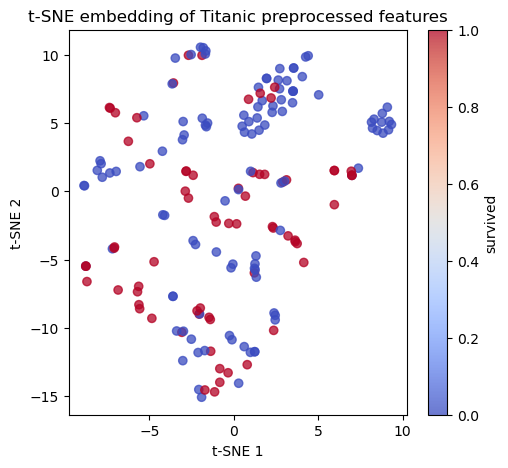

In [12]:
# Transform the test set through the preprocessor so we visualize the same feature space used by the model.
X_test_transformed = preprocessor.transform(X_test)
print("Transformed test set shape:", X_test_transformed.shape)

# t-SNE embedding
X_tsne = TSNE(n_components=2, random_state=42, learning_rate="auto", init="pca").fit_transform(X_test_transformed)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_test, cmap="coolwarm", alpha=0.75)
plt.title("t-SNE embedding of Titanic preprocessed features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="survived")

/opt/anaconda3/envs/ML_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/ML_env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/ML_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


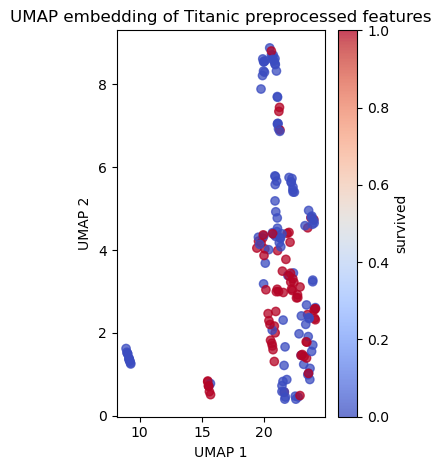

In [13]:
umap_spec = importlib.util.find_spec("umap")
if umap_spec is not None:
    import umap
    X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_test_transformed)
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_test, cmap="coolwarm", alpha=0.75)
    plt.title("UMAP embedding of Titanic preprocessed features")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.colorbar(scatter, label="survived")
    plt.tight_layout()
    plt.show()
else:
    plt.tight_layout()
    plt.show()
    print("UMAP is not installed. Install it with `pip install umap-learn` to run the UMAP section.")

## 13. Summary
- `Pipeline` keeps preprocessing and model training together.
- Nested objects like `ColumnTransformer` and `Pipeline` support flexible workflows.
- Use `named_steps` and parameter prefixes to inspect and tune every component.
- Saving the full pipeline with `joblib` preserves the exact production workflow.

Next steps:
- Add a `GridSearchCV` wrapper around the pipeline.
- Create a custom transformer for domain-specific feature engineering.
- Use `Pipeline` with cross-validation directly to avoid leakage.